# REGRESIÓN LOGÍSTICA

Es un tipo de clasificador lineal que no predice valores continuos (NO CONFUNDIR AUNQUE SE LLAMA REGRESIÓN ES UN MODELO DE CLASIFICACIÓN).

Predice la probabilidad de pertenecer a una clase

Empieza como regresión lineal -> aplicas función sigmoide 

In [32]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path().resolve().parents[1]

data = pd.read_csv(DATA_ROOT / "datasets/machine_learning_data/casoB_clinico_con_problemas.csv")

Se analiza el dataset

In [33]:
data.head()

,patient_id,exam_date,age,tumor_size_mm,mean_texture,mean_radius,lymph_nodes,family_history,hormone_therapy,calcification_score,malignant
0,80904.0,2023-04-15,47.0,21.8,18.83,12.46,2.0,0.0,0.0,136.0,0
1,80240.0,2023-05-06,44.0,21.0,16.70,11.38,3.0,0.0,1.0,110.7,0
2,80429.0,2023-02-07,58.0,3.0,18.41,15.19,1.0,0.0,1.0,113.1,1
3,80947.0,2023-01-17,22.0,10.6,20.98,17.13,1.0,1.0,0.0,136.4,1
4,80147.0,2023-09-18,52.0,10.5,20.51,8.74,2.0,1.0,0.0,129.7,1


In [34]:
print(data.shape)
print(data.dtypes)

(1020, 11)
patient_id             float64
exam_date                  str
age                    float64
tumor_size_mm          float64
mean_texture           float64
mean_radius            float64
lymph_nodes            float64
family_history         float64
hormone_therapy        float64
calcification_score    float64
malignant                int64
dtype: object


In [35]:
# numero de duplicados del dataset
print(f"Cantidad de registros duplicados: {data.duplicated().sum()}")

data.isna().sum().to_frame("n_nulos").T

Cantidad de registros duplicados: 14


,patient_id,exam_date,age,tumor_size_mm,mean_texture,mean_radius,lymph_nodes,family_history,hormone_therapy,calcification_score,malignant
n_nulos,11,14,16,11,12,9,5,11,10,8,0


In [40]:
# eliminamos duplicados exactos y reseteamos el indice quitando la columna que se pueda llegar a generar
data = data.drop_duplicates().reset_index(drop=True)

In [54]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,995.0,80498.712563,288.282491,80000.00,80250.5000,80498.000,80747.5000,80999.00
age,990.0,53.692929,10.824954,20.00,46.2500,54.000,60.0000,89.00
tumor_size_mm,995.0,22.502111,16.206296,3.00,10.8000,19.000,30.0500,105.10
mean_texture,994.0,17.983350,3.907951,7.00,15.2025,17.935,20.5775,30.35
mean_radius,997.0,14.108957,2.595746,6.03,12.3900,14.120,15.7100,23.18
lymph_nodes,1001.0,1.673327,1.308502,0.00,1.0000,1.000,2.0000,7.00
family_history,995.0,0.362814,0.481054,0.00,0.0000,0.000,1.0000,1.00
hormone_therapy,996.0,0.231928,0.422275,0.00,0.0000,0.000,0.0000,1.00
calcification_score,998.0,124.569739,22.082935,57.20,110.0250,124.400,139.5750,192.40
malignant,1006.0,0.506958,0.500200,0.00,0.0000,1.000,1.0000,1.00


array([[<Axes: title={'center': 'patient_id'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'tumor_size_mm'}>],
       [<Axes: title={'center': 'mean_texture'}>,
        <Axes: title={'center': 'mean_radius'}>,
        <Axes: title={'center': 'lymph_nodes'}>],
       [<Axes: title={'center': 'family_history'}>,
        <Axes: title={'center': 'hormone_therapy'}>,
        <Axes: title={'center': 'calcification_score'}>],
       [<Axes: title={'center': 'malignant'}>, <Axes: >, <Axes: >]],
      dtype=object)

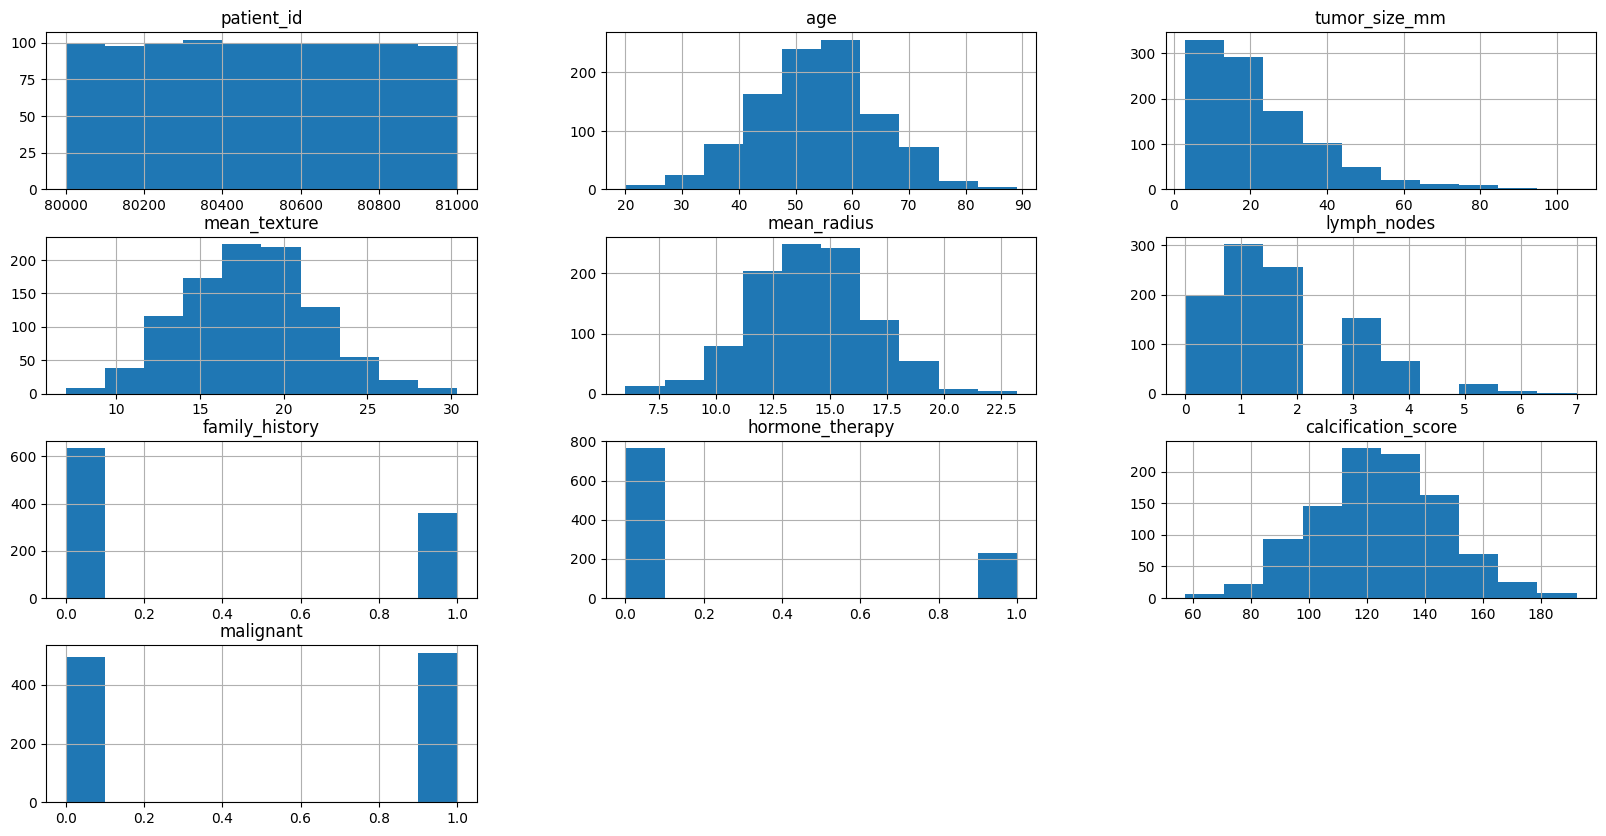

In [55]:
data.hist(figsize=(20,10))

In [59]:
data.dtypes

patient_id             float64
exam_date                  str
age                    float64
tumor_size_mm          float64
mean_texture           float64
mean_radius            float64
lymph_nodes            float64
family_history         float64
hormone_therapy        float64
calcification_score    float64
malignant                int64
dtype: object

In [ ]:
data['malignant'] = pd.to_numeric(data['malignant'], errors="coerce") # en caso de error salta Nan

import numpy as np
data = data.replace([np.inf, -np.inf], np.nan)

# si filtras y luego añades o modificas columnas, pon .copy(). Si solo filtras para leer o pasar a un modelo, no hace falta
data = data.dropna(subset=['malignant']).copy()


In [69]:
# creamos features eliminando las columnas que no son parte
cols_to_drop = ['patient_id', 'exam_date', 'malignant']

X = data.drop(columns=cols_to_drop)
y = data["malignant"] # una SERIE recordar

In [68]:
X.head()

,age,tumor_size_mm,mean_texture,mean_radius,lymph_nodes,family_history,hormone_therapy,calcification_score
0,47.0,21.8,18.83,12.46,2.0,0.0,0.0,136.0
1,44.0,21.0,16.70,11.38,3.0,0.0,1.0,110.7
2,58.0,3.0,18.41,15.19,1.0,0.0,1.0,113.1
3,22.0,10.6,20.98,17.13,1.0,1.0,0.0,136.4
4,52.0,10.5,20.51,8.74,2.0,1.0,0.0,129.7


In [67]:
y.head()

0    0
1    0
2    1
3    1
4    1
Name: malignant, dtype: int64

In [82]:
# vemos si el target esta bien distribuido
(y.value_counts(normalize=True) * 100).round(1).rename({1:"maligno", 0: "benigno"}).to_frame("porcentaje nulo")

,porcentaje nulo
malignant,
maligno,50.7
benigno,49.3
